In [70]:
%%capture
!pip install datasets transformers

In [71]:
from transformers import BertTokenizer
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
from datasets import load_dataset
import unicodedata
import re

## Tokenizer


In [72]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

In [73]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [74]:
sent = "I love footballing"
ids = tokenizer.encode(sent)
for i in ids:
    print(i, tokenizer.convert_ids_to_tokens(i))

101 [CLS]
1045 i
2293 love
2374 football
2075 ##ing
102 [SEP]


**Dataset**

We will use the IMDB dataset. It is a dataset with 2 classes: Positive and Negative. We download it from HuggingFace Hub [here](https://huggingface.co/datasets/fancyzhx/ag_news)

We will use only a very small subset of **64** annotated texts. This is a paradigm called "few shots learnings".


In [75]:
dataset = load_dataset("stanfordnlp/imdb")
dataset = dataset["train"]
dataset = dataset.shuffle(seed=42)
dataset = dataset.train_test_split(test_size=0.3, seed=1234)
dataset["train"] = dataset["train"].select(range(64))
dataset["test"] = dataset["test"].select(range(1000))

print(dataset)


def preprocess_text(x):
    # TODO lower case
    text = x["text"]
    text = text.lower()

    # TODO string normalization.
    text = unicodedata.normalize("NFD", text).encode("ascii", "ignore").decode()

    # TODO remove non alpha numeric characters.
    text = re.sub(r"[^a-z0-9]", " ", text)

    # TODO replace numbers by the <NUM> token.
    text = re.sub(r"\d+", "<NUM>", text)

    # TODO remove double whitespaces.
    text = re.sub(" +", " ", text.strip())
    ids = tokenizer(text, truncation=True, max_length=256, padding=False)["input_ids"]
    return {"input_ids": ids}


# Clean the dataset and tokenize it directly
dataset = dataset.map(preprocess_text)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 64
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})


In [76]:
class DataCollator:
    def __init__(self, tokenizer, max_len=128):
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __call__(self, batch):
        # Tokenize the texts
        labels = [example["label"] for example in batch]
        tokenized_texts = [example["input_ids"] for example in batch]
        # Pad the tokenized texts
        max_len = max(len(text) for text in tokenized_texts)
        padded_texts = [
            text + [self.tokenizer.pad_token_id] * (max_len - len(text))
            for text in tokenized_texts
        ]
        pad_mask = [
            [1] * len(text) + [0] * (max_len - len(text)) for text in tokenized_texts
        ]
        return {
            "input_ids": torch.tensor(padded_texts),
            "pad_mask": torch.tensor(pad_mask),
            "labels": torch.tensor(labels),
        }

In [77]:
# TODO
def validation_step(valid_dataloader, model, criterion):
    n_valid = len(valid_dataloader.dataset)
    model.eval()
    total_loss = 0.0
    correct = 0
    n_iter = 0
    with torch.no_grad():
        for batch in valid_dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            pad_mask = batch["pad_mask"].to(DEVICE)
            output = model(input_ids, pad_mask)
            loss = criterion(output, labels)
            total_loss += loss.item()
            correct += (output.argmax(axis=-1) == labels).sum().item()
            n_iter += 1
    return total_loss / n_iter, correct / n_valid


def train_one_epoch(train_dataloader, model, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    n_train = len(train_dataloader.dataset)
    n_iter = 0
    for batch in train_dataloader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        pad_mask = batch["pad_mask"].to(DEVICE)
        class_scores = model(input_ids, pad_mask)  # (B, 4)

        loss = criterion(class_scores, labels)  # scalaire (1,)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (class_scores.argmax(axis=-1) == labels).sum().item()
        n_iter += 1

    return total_loss / n_iter, correct / n_train


def train(model, train_dataloader, valid_dataloader, lr=0.01, n_epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Track training loss, training accuracy, validation loss and validation accuracy and plot in the end
    train_losses = []
    train_accuracies = []
    valid_losses = []
    valid_accuracies = []
    model.to(DEVICE)
    for epoch in range(n_epochs):
        train_loss, train_accuracy = train_one_epoch(
            train_dataloader, model, optimizer, criterion
        )
        valid_loss, valid_accuracy = validation_step(valid_dataloader, model, criterion)
        print(
            f"Epoch {epoch + 1}: train_loss: {train_loss:.4f}, train_accuracy: {train_accuracy:.4f}, valid_loss: {valid_loss:.4f}, valid_accuracy: {valid_accuracy:.4f}"
        )
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="train loss")
    plt.plot(valid_losses, label="valid loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="train accuracy")
    plt.plot(valid_accuracies, label="valid accuracy")
    plt.legend()

In [78]:
batch_size = 4
n_train = len(dataset["train"])
n_valid = len(dataset["test"])
data_collator = DataCollator(tokenizer)
train_dataloader = DataLoader(
    dataset["train"], batch_size=batch_size, collate_fn=data_collator, shuffle=True
)
valid_dataloader = DataLoader(
    dataset["test"], batch_size=batch_size, collate_fn=data_collator, shuffle=True
)

In [79]:
class WordEmbedClassifier(nn.Module):
    def __init__(self, vocab_size, d, n_classes=4):
        super().__init__()
        self.embedding_layer = nn.Embedding(vocab_size, d)
        self.class_projection = nn.Linear(d, n_classes)

    def forward(self, input_ids, pad_mask):
        x_embed = self.embedding_layer(input_ids)  # (B, L, d)

        # x_vector = x_embeds.mean(axis=1) # (B, d)
        n_non_pad = pad_mask.sum(
            axis=1, keepdim=True
        )  # (B, 1), 1 because of keepdim=True

        # pad_mask (B, L), x_embed (B, L, d)
        x_embed = x_embed * pad_mask[:, :, None]  # or pad_mask.unsqueeze(-1)
        x_vector = x_embed.sum(axis=1) / n_non_pad

        class_scores = self.class_projection(x_vector)  # (B, n_classes)

        return class_scores

In [80]:
def load_model(model, w2v_path):
    """
    Loads pre-trained Word2Vec embeddings from a .ckpt file
    into the model's embedding layer.
    """
    # Load the saved tensor (shape: [vocab_size, d])
    pretrained_weights = torch.load(w2v_path)

    # Check if dimensions match (d must be the same as defined in your classifier)
    if model.embedding_layer.weight.shape != pretrained_weights.shape:
        print(f"Error: Dimension mismatch!")
        print(f"Model needs: {model.embedding_layer.weight.shape}")
        print(f"File provides: {pretrained_weights.shape}")
        return

    # Copy the weights into the embedding layer
    model.embedding_layer.weight.data.copy_(pretrained_weights)
    print(f"Successfully loaded embeddings from {w2v_path}")

    # Optional: Freeze the weights if you don't want them to change during few-shot training
    # model.embedding_layer.weight.requires_grad = False

Loading Small Word2Vec model...
Successfully loaded embeddings from ./model_dim-64_radius-5_ratio-5-batch-512-epoch-5.ckpt

Training Small model (Few-Shot)...
Epoch 1: train_loss: 0.7040, train_accuracy: 0.4531, valid_loss: 0.6906, valid_accuracy: 0.5170
Epoch 2: train_loss: 0.6019, train_accuracy: 0.7969, valid_loss: 0.6636, valid_accuracy: 0.6310
Epoch 3: train_loss: 0.4592, train_accuracy: 0.9219, valid_loss: 0.6523, valid_accuracy: 0.6190
Epoch 4: train_loss: 0.2943, train_accuracy: 0.9844, valid_loss: 0.6318, valid_accuracy: 0.6420
Epoch 5: train_loss: 0.1326, train_accuracy: 1.0000, valid_loss: 0.6292, valid_accuracy: 0.6640
Epoch 6: train_loss: 0.0662, train_accuracy: 1.0000, valid_loss: 0.6146, valid_accuracy: 0.6590
Epoch 7: train_loss: 0.0353, train_accuracy: 1.0000, valid_loss: 0.6130, valid_accuracy: 0.6640
Epoch 8: train_loss: 0.0213, train_accuracy: 1.0000, valid_loss: 0.6146, valid_accuracy: 0.6620
Epoch 9: train_loss: 0.0150, train_accuracy: 1.0000, valid_loss: 0.6178, 

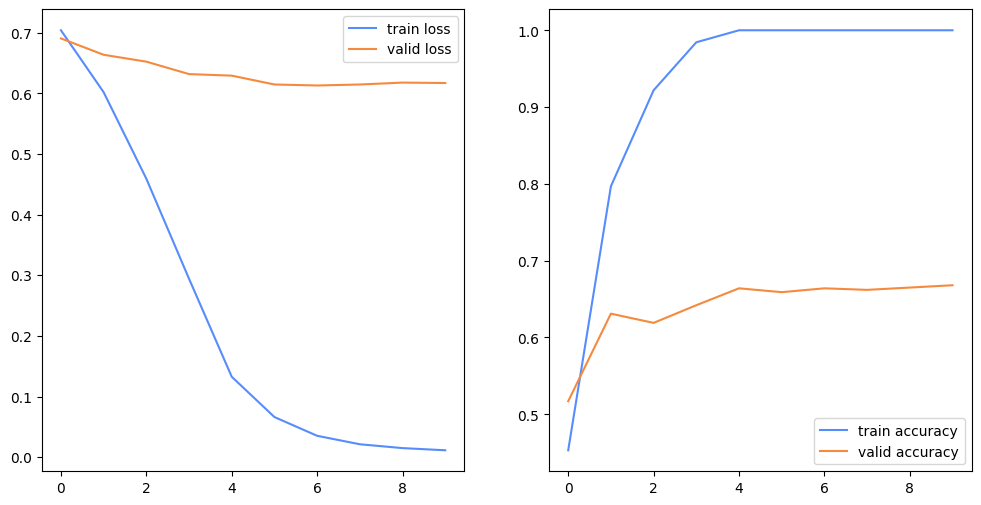

In [81]:
# --- Experiment 1: Ablation Study (Small Model) ---
PATH_W2V_SMALL = "./model_dim-64_radius-5_ratio-5-batch-512-epoch-5.ckpt"

# 1. Initialize the classifier for dimension 64
model_ablation_small = WordEmbedClassifier(
    vocab_size=len(tokenizer),
    d=64,            # Must match your ablation checkpoint dimension
    n_classes=2
)

# 2. LOAD the smaller pre-trained weights
print("Loading Small Word2Vec model...")
load_model(model_ablation_small, PATH_W2V_SMALL)

# 3. Train on the 64 samples for comparison
print("\nTraining Small model (Few-Shot)...")
train(
    model_ablation_small,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    lr=0.01,
    n_epochs=10
)

Loading Large Word2Vec model...
Successfully loaded embeddings from ./model_dim-128_radius-5_ratio-5-batch-512-epoch-10.ckpt

Training Large model (Few-Shot)...
Epoch 1: train_loss: 0.6932, train_accuracy: 0.4375, valid_loss: 0.6854, valid_accuracy: 0.5170
Epoch 2: train_loss: 0.5369, train_accuracy: 0.8438, valid_loss: 0.6476, valid_accuracy: 0.6350
Epoch 3: train_loss: 0.3263, train_accuracy: 1.0000, valid_loss: 0.6151, valid_accuracy: 0.6760
Epoch 4: train_loss: 0.1212, train_accuracy: 1.0000, valid_loss: 0.5877, valid_accuracy: 0.6870
Epoch 5: train_loss: 0.0398, train_accuracy: 1.0000, valid_loss: 0.5803, valid_accuracy: 0.6900
Epoch 6: train_loss: 0.0172, train_accuracy: 1.0000, valid_loss: 0.5837, valid_accuracy: 0.6880
Epoch 7: train_loss: 0.0099, train_accuracy: 1.0000, valid_loss: 0.5851, valid_accuracy: 0.6920
Epoch 8: train_loss: 0.0071, train_accuracy: 1.0000, valid_loss: 0.5832, valid_accuracy: 0.6930
Epoch 9: train_loss: 0.0054, train_accuracy: 1.0000, valid_loss: 0.5859

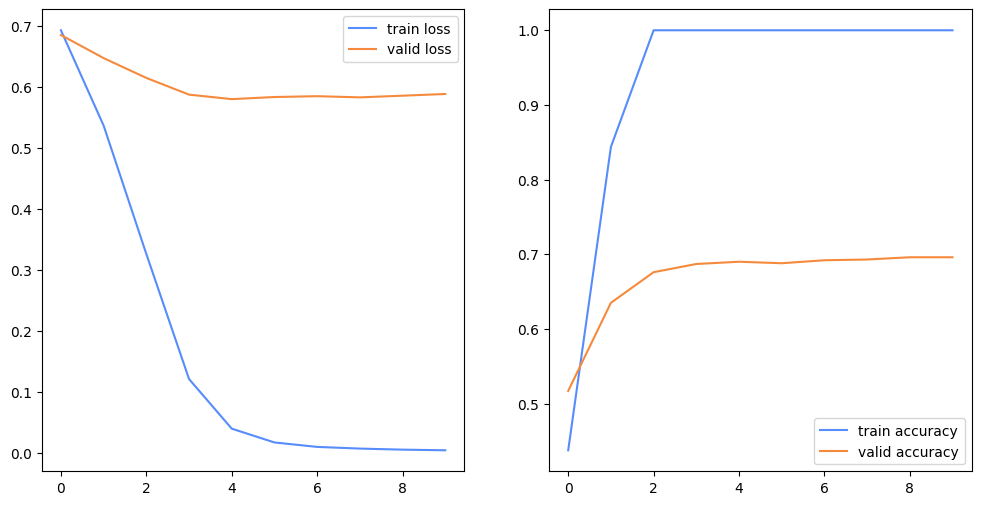

In [82]:
# --- Experiment 2: Ablation Study (Large Model) ---
PATH_W2V_LARGE = "./model_dim-128_radius-5_ratio-5-batch-512-epoch-10.ckpt"

# 1. Initialize the classifier for dimension 128
model_w2v_large = WordEmbedClassifier(
    vocab_size=len(tokenizer),
    d=128,           # Must match your checkpoint dimension
    n_classes=2      # IMDB is binary (Positive/Negative)
)

# 2. LOAD the pre-trained weights before training
print("Loading Large Word2Vec model...")
load_model(model_w2v_large, PATH_W2V_LARGE)

# 3. Train on the 64 samples (Few-Shot paradigm)
print("\nTraining Large model (Few-Shot)...")
train(
    model_w2v_large,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    lr=0.01,
    n_epochs=10
)

Starting Baseline model training (Random Initialization)...
Epoch 1: train_loss: 0.7132, train_accuracy: 0.4531, valid_loss: 0.6822, valid_accuracy: 0.5400
Epoch 2: train_loss: 0.5196, train_accuracy: 0.8281, valid_loss: 0.6582, valid_accuracy: 0.6110
Epoch 3: train_loss: 0.3126, train_accuracy: 0.9688, valid_loss: 0.6291, valid_accuracy: 0.6350
Epoch 4: train_loss: 0.1268, train_accuracy: 1.0000, valid_loss: 0.6176, valid_accuracy: 0.6490
Epoch 5: train_loss: 0.0470, train_accuracy: 1.0000, valid_loss: 0.6171, valid_accuracy: 0.6660
Epoch 6: train_loss: 0.0197, train_accuracy: 1.0000, valid_loss: 0.6160, valid_accuracy: 0.6640
Epoch 7: train_loss: 0.0115, train_accuracy: 1.0000, valid_loss: 0.6181, valid_accuracy: 0.6680
Epoch 8: train_loss: 0.0080, train_accuracy: 1.0000, valid_loss: 0.6224, valid_accuracy: 0.6740
Epoch 9: train_loss: 0.0061, train_accuracy: 1.0000, valid_loss: 0.6246, valid_accuracy: 0.6730
Epoch 10: train_loss: 0.0048, train_accuracy: 1.0000, valid_loss: 0.6268, va

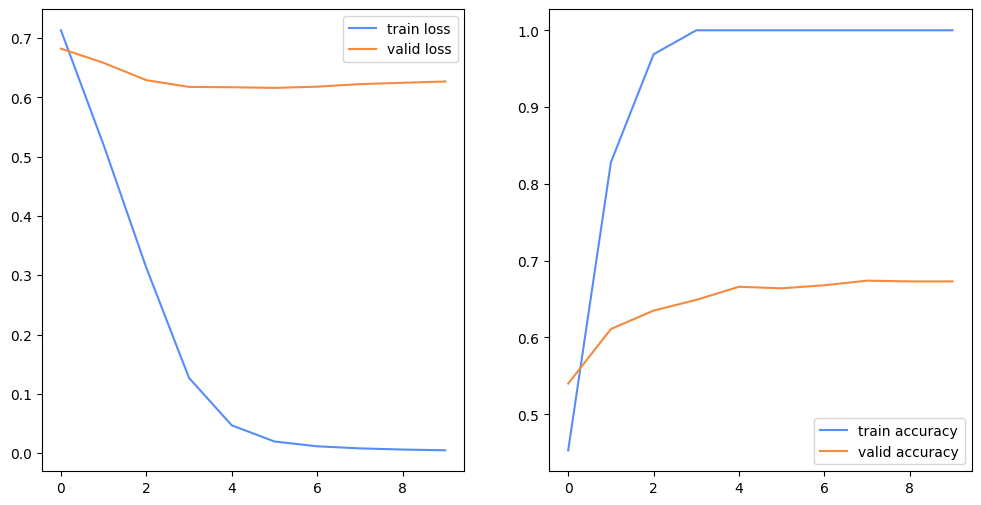

In [83]:
# --- Experiment 3: Baseline (Random Initialization) ---

# 1. Initialize the classifier with random weights
# We use d=128 to match the Large Word2Vec model for a fair comparison
model_baseline = WordEmbedClassifier(
    vocab_size=len(tokenizer),
    d=128,           # Matching the dimension of your best Word2Vec model
    n_classes=2      # IMDB is binary (Positive/Negative)
)

# 2. Train the baseline model from scratch
# No load_model() is called here to simulate learning without pre-training
print("Starting Baseline model training (Random Initialization)...")
train(
    model_baseline,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    lr=0.01,
    n_epochs=10
)